In [1]:
import torch

In [7]:
#pip install d2l

In [3]:
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PositiveDefiniteTransform', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'Transform', 'TransformedDistribution',

In [6]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [8]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [10]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [11]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)

(1460, 81)
(1459, 80)


In [12]:
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [13]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
# Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
        self.raw_val.drop(columns=['Id'])))
# Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
# Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
# Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
# Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()

In [14]:
data.preprocess()
data.train.shape

(1460, 331)

In [15]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
        dtype=torch.float32)
# Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])), # X
                torch.log(get_tensor(data[label])).reshape((-1, 1))) # Y
    return self.get_tensorloader(tensors, train)
    

In [16]:
def k_fold_data(data, k):
    rets = []
    fold_size = data.train.shape[0] // k
    for j in range(k):
        idx = range(j * fold_size, (j+1) * fold_size)
        rets.append(KaggleHouse(data.batch_size, data.train.drop(index=idx),
                                data.train.loc[idx]))
    return rets

In [17]:
def k_fold(trainer, data, k, lr):
    val_loss, models = [], []
    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = d2l.LinearRegression(lr)
        model.board.yscale='log'
        if i != 0: model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append(model)
    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return models

/Users/jukkasalmenkyla/anaconda3/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/jukkasalmenkyla/anaconda3/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/jukkasalmenkyla/anaconda3/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/jukkasalmenkyla/anaconda3/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning

average validation log mse = 0.19519378930330275


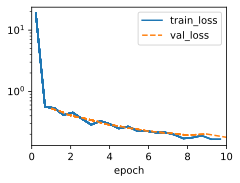

In [18]:
trainer = d2l.Trainer(max_epochs=10)
models = k_fold(trainer, data, k=5, lr=0.01)

In [20]:
preds = [model(torch.tensor(data.val.values.astype(float), dtype=torch.float32))
        for model in models]
# Taking exponentiation of predictions in the logarithm scale
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)
submission = pd.DataFrame({'Id':data.raw_val.Id,
                            'SalePrice':ensemble_preds.detach().numpy()})
submission.to_csv('submission.csv', index=False)

In [21]:
ls

ArxivPapers/              arxiv/                    libraries.txt
ArxivSummaries/           arxiv.py                  requirements.txt
DBMS/                     arxiv_cron.log            run_arxiv.sh*
DiveIntoDL/               arxiv_fetch2.py           run_arxiv_scraper.sh*
LICENSE                   arxiv_scraper.py          setup.py
README.md                 dynamic_arxiv_scraper.py  submission.csv
Untitled1.ipynb           fetch_arxiv.sh*           topics.txt


In [25]:
import os
os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('''NumRooms,RoofType,Price
    NA,NA,127500
    2,NA,106000
    4,Slate,178100
    NA,NA,140000''')

In [26]:
import pandas as pd
data = pd.read_csv(data_file)
print(data)

  NumRooms RoofType   Price
0       NA      NaN  127500
1        2      NaN  106000
2        4    Slate  178100
3       NA      NaN  140000


In [27]:
inputs, targets = data.iloc[:, 0:2], data.iloc[:, 2]
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)

   NumRooms_    2  NumRooms_    4  NumRooms_    NA  NumRooms_nan  \
0           False           False             True         False   
1            True           False            False         False   
2           False            True            False         False   
3           False           False             True         False   

   RoofType_Slate  RoofType_nan  
0           False          True  
1           False          True  
2            True         False  
3           False          True  


In [28]:
inputs = inputs.fillna(inputs.mean())
print(inputs)

   NumRooms_    2  NumRooms_    4  NumRooms_    NA  NumRooms_nan  \
0           False           False             True         False   
1            True           False            False         False   
2           False            True            False         False   
3           False           False             True         False   

   RoofType_Slate  RoofType_nan  
0           False          True  
1           False          True  
2            True         False  
3           False          True  


In [29]:
import torch
X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(targets.to_numpy(dtype=float))
X, y

(tensor([[0., 0., 1., 0., 0., 1.],
         [1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 0., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

In [30]:
A = torch.arange(6).reshape(3, 2)
A

tensor([[0, 1],
        [2, 3],
        [4, 5]])

In [31]:
A.T

tensor([[0, 2, 4],
        [1, 3, 5]])

In [32]:
A = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
A == A.T

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

In [33]:
torch.arange(24).reshape(2, 3, 4)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [34]:
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone() # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

In [40]:
x

tensor([0., 1., 2.])

In [37]:
x = torch.arange(3, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2.]), tensor(3.))

In [41]:
y

tensor([1., 1., 1.])

In [38]:
y = torch.ones(3, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2.]), tensor([1., 1., 1.]), tensor(3.))

In [39]:
torch.sum(x * y)

tensor(3.)

In [42]:
A.shape, x.shape, torch.mv(A, x), A@x

(torch.Size([2, 3]), torch.Size([3]), tensor([ 5., 14.]), tensor([ 5., 14.]))

In [43]:
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone() # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

In [44]:
A * B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

In [45]:
A.shape

torch.Size([2, 3])

In [46]:
A

tensor([[0., 1., 2.],
        [3., 4., 5.]])

In [47]:
A.sum(axis=[0, 1]) == A.sum() # Same as A.sum()

tensor(True)

In [48]:
A.numel()

6

In [49]:
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

In [58]:
torch.abs(u).sum()

tensor(7.)

In [55]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

In [56]:
def f(x):
    return 3 * x ** 2 - 4 * x

In [57]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [ ]:
# Visualization Utilities

In [60]:
def use_svg_display(): #@save
    """Use the svg format to display a plot in Jupyter."""
    backend_inline.set_matplotlib_formats('svg')

In [61]:
def set_figsize(figsize=(3.5, 2.5)): #@save
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [63]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim), axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [64]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
        ylim=None, xscale='linear', yscale='linear',
        fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X): # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
            and not hasattr(X[0], "__len__"))
    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

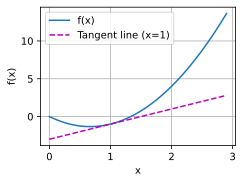

In [65]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

In [66]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [67]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad # The gradient is None by default

In [68]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [69]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [70]:
x.grad == 4 * x

tensor([True, True, True, True])

In [71]:
x.grad.zero_() # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [73]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

In [74]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [44, 56]


In [75]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([51., 49.])

In [76]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.5100, 0.4900])

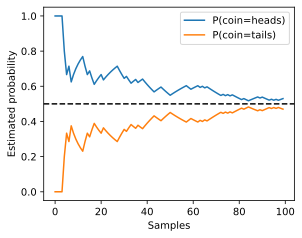

In [78]:
counts = Multinomial(1, fair_probs).sample((100,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()
d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

In [80]:
#print(dir(torch.distributions))
print(dir(torch.cuda))

['Any', 'BFloat16Storage', 'BFloat16Tensor', 'BoolStorage', 'BoolTensor', 'ByteStorage', 'ByteTensor', 'CUDAGraph', 'CUDAPluggableAllocator', 'CharStorage', 'CharTensor', 'ComplexDoubleStorage', 'ComplexFloatStorage', 'CudaError', 'DeferredCudaCallError', 'Device', 'DoubleStorage', 'DoubleTensor', 'Event', 'ExternalStream', 'FloatStorage', 'FloatTensor', 'HalfStorage', 'HalfTensor', 'IntStorage', 'IntTensor', 'List', 'LongStorage', 'LongTensor', 'Optional', 'OutOfMemoryError', 'ShortStorage', 'ShortTensor', 'Stream', 'StreamContext', 'Tuple', 'Union', '_CudaBase', '_CudaDeviceProperties', '_DeviceGuard', '_LazySeedTracker', '__all__', '__annotations__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_check_capability', '_check_cubins', '_cudart', '_device', '_device_count_nvml', '_device_t', '_dummy_type', '_exchange_device', '_get_device_index', '_initialization_lock', '_initialized', '_is_compiled', '_is_in_bad_f

In [87]:
help(torch.cuda)

Object `help(torch.cuda)` not found.


In [86]:
list?

In [88]:
torch.cuda?